In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential

In [23]:
model=Sequential([Input((224, 224, 3)),
                Conv2D(16, (5,5), activation='relu'),
                MaxPooling2D((2,2)),
                Conv2D(16, (5,5), activation='relu'),
                MaxPooling2D((2,2)),
                Flatten(),
                Dense(64, activation='relu'),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid'),
                ])

In [24]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
# import kaggle

In [26]:
# !kaggle datasets download -d tongpython/cat-and-dog

In [27]:
import zipfile
with zipfile.ZipFile(r"C:\xampp816\htdocs\personal-dev\py-ds\deeplearning\CNN\cat_dog.zip", "r") as obj1:
    obj1.extractall()

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [29]:
train_gen=ImageDataGenerator(rescale=1./255) # brightness_range=0.1, rotation_range=0.3, zoom_range=0.3 --> other params to augment available image set if image data is low
train_data = train_gen.flow_from_directory(r'C:\xampp816\htdocs\personal-dev\py-ds\deeplearning\CNN\training_set\training_set', target_size=(224,224), class_mode='binary')

Found 8005 images belonging to 2 classes.


In [30]:
test_gen=ImageDataGenerator(rescale=1./255) # brightness_range=0.1, rotation_range=0.3, zoom_range=0.3 --> other params to augment available image set if image data is low
test_data = test_gen.flow_from_directory(r'C:\xampp816\htdocs\personal-dev\py-ds\deeplearning\CNN\test_set\test_set', target_size=(224,224), class_mode='binary', shuffle=False)

Found 2023 images belonging to 2 classes.


In [31]:
model.fit(train_data, epochs=8)

c:\Users\rijok\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 293ms/step - accuracy: 0.5224 - loss: 0.7333
Epoch 2/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 287ms/step - accuracy: 0.6520 - loss: 0.6404
Epoch 3/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 291ms/step - accuracy: 0.7362 - loss: 0.5293
Epoch 4/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 279ms/step - accuracy: 0.8531 - loss: 0.3491
Epoch 5/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 277ms/step - accuracy: 0.9428 - loss: 0.1619
Epoch 6/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 272ms/step - accuracy: 0.9868 - loss: 0.0437
Epoch 7/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 309ms/step - accuracy: 0.9877 - loss: 0.0394
Epoch 8/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 214ms/step - accuracy: 0.9942 - loss: 0.0236


In [32]:
y_pred=model.predict(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step


In [33]:
y_pred=(y_pred>0.5).flatten()
y_pred

array([ True, False, False, ..., False,  True,  True])

In [34]:
test_data.class_indices

{'cats': 0, 'dogs': 1}

In [35]:
test_data.classes.shape

(2023,)

In [36]:
y_test=test_data.classes

In [37]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.75      0.68      1011
           1       0.69      0.57      0.62      1012

    accuracy                           0.66      2023
   macro avg       0.66      0.66      0.65      2023
weighted avg       0.66      0.66      0.65      2023



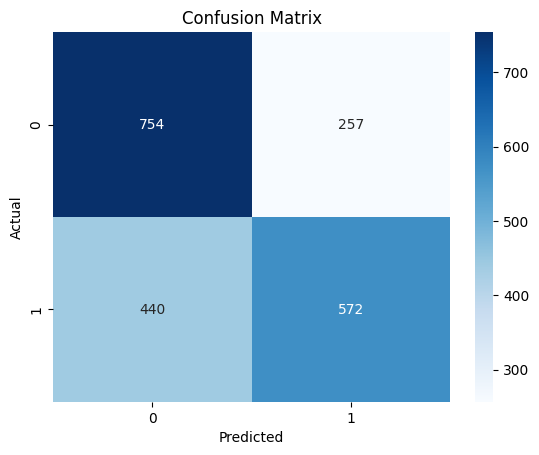

In [38]:
import seaborn as sns

# plt.figure(figsize=(3,3))
sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
import cv2
img_array=cv2.imread(r'C:\xampp816\htdocs\personal-dev\py-ds\deeplearning\CNN\test_set\test_set\dogs\dog.4097.jpg') # 0 --> grayscale
img_array=cv2.resize(img_array, (224, 224)) # width, height

In [40]:
img_array=img_array.reshape((1, 224, 224, 3))/255
img_array.shape

(1, 224, 224, 3)

In [41]:
result=model.predict(img_array)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


array([[0.9568657]], dtype=float32)

In [43]:
from tensorflow.keras.applications.vgg16 import VGG16

In [44]:
base_model=VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 38s 1us/step


In [45]:
for layer in base_model.layers:
    layer.trainable=False

In [46]:
model=Sequential([base_model,
                Flatten(),
                Dense(200, activation='relu'),
                Dense(200, activation='relu'),
                Dense(1, activation='sigmoid'),
                ])

In [48]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [49]:
model.fit(train_data)

251/251 ━━━━━━━━━━━━━━━━━━━━ 1164s 5s/step - accuracy: 0.8312 - loss: 0.4252
